# 04. 비지도학습 (Unsupervised Learning)
### K-Means / PCA / t-SNE
---

## 0. 라이브러리 불러오기

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from scipy.sparse import load_npz
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로딩 완료 ✅')

라이브러리 로딩 완료 ✅


---
## 1. 데이터 불러오기

In [15]:
# TF-IDF 행렬 (전체 데이터 사용)
X_train = load_npz('../data/preprocessed/X_train_tfidf.npz')
X_test  = load_npz('../data/preprocessed/X_test_tfidf.npz')

# 전체 합치기 (비지도학습은 label 불필요)
from scipy.sparse import vstack
X_all = vstack([X_train, X_test])

# 원본 데이터
df = pd.read_csv('../data/preprocessed/reviews_clean.csv', encoding='utf-8-sig')

# X_all → df 원본 인덱스 매핑
# X_all = [X_train | X_test] 순서이고, train/test split 순서가 df 순서와 다르므로 매핑 필요
y_clf_train = pd.read_csv('../data/preprocessed/y_clf_train.csv', index_col=0).squeeze()
y_clf_test  = pd.read_csv('../data/preprocessed/y_clf_test.csv',  index_col=0).squeeze()
all_original_idx = list(y_clf_train.index) + list(y_clf_test.index)  # X_all[i] → df.loc[all_original_idx[i]]

# TF-IDF 벡터라이저
with open('../data/preprocessed/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

feature_names = tfidf.get_feature_names_out()

print('데이터 로딩 완료 ✅')
print(f'전체 데이터 shape : {X_all.shape}')
print(f'원본 데이터 수    : {len(df):,}개')

데이터 로딩 완료 ✅
전체 데이터 shape : (199171, 10000)
원본 데이터 수    : 199,171개


---
## 2. PCA (주성분 분석)
> 고차원(10,000개) 데이터를 저차원으로 압축
>
> 비지도학습 + 시각화 목적

```
10,000차원  →  PCA  →  2차원
시각화 불가        →  2D 그래프로 표현 가능
```

In [16]:
print('PCA 변환 중...')

# sparse matrix → dense 변환 (샘플링)
# 전체 데이터는 너무 많으므로 10,000개 샘플링
np.random.seed(42)
sample_idx     = np.random.choice(X_all.shape[0], size=10000, replace=False)
X_sample       = X_all[sample_idx].toarray()
sample_df_idx  = [all_original_idx[i] for i in sample_idx]  # X_all 위치 → df 원본 인덱스
df_sample      = df.loc[sample_df_idx].copy()                 # 올바른 df 행 선택

# PCA 적용
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

print('PCA 변환 완료 ✅')
print(f'설명된 분산 비율 : {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'  PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%')

PCA 변환 중...
PCA 변환 완료 ✅
설명된 분산 비율 : 1.54%
  PC1 : 0.85%
  PC2 : 0.69%


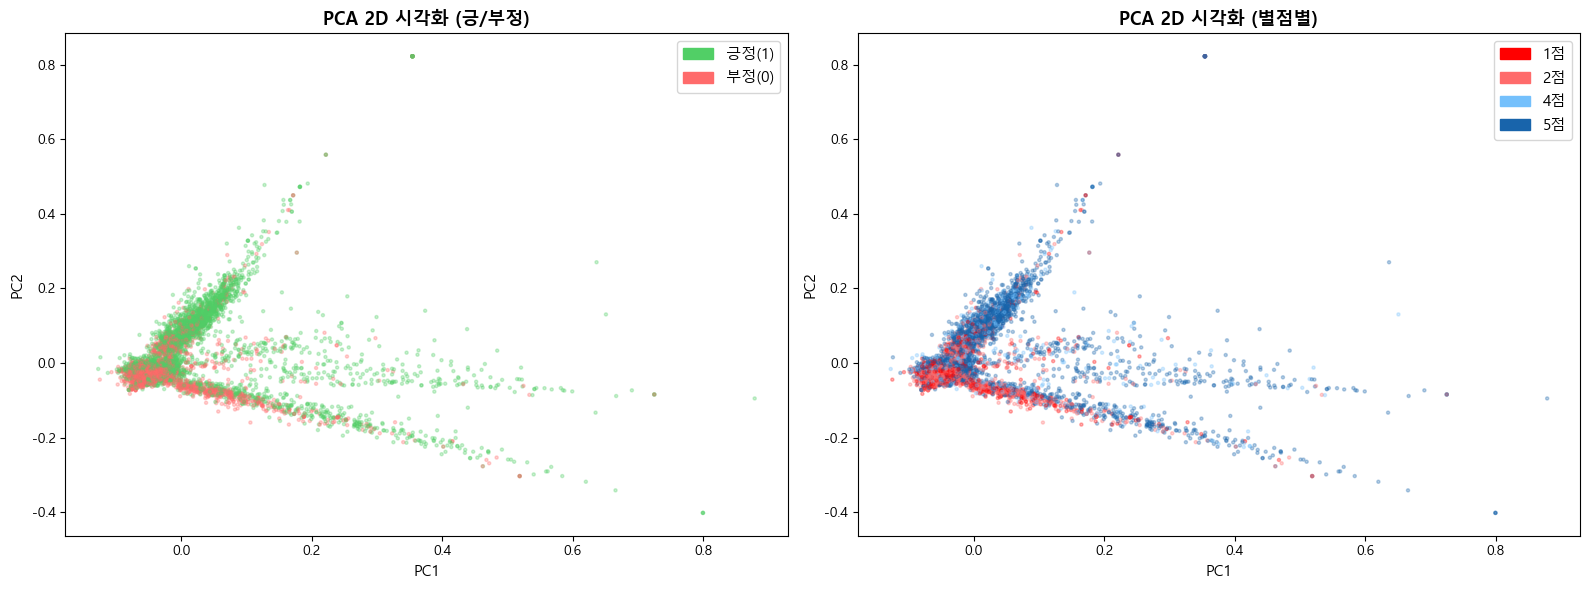

저장 완료 ✅


In [17]:
# PCA 시각화 (긍/부정 색상 구분)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 긍/부정 색상 매핑
colors = df_sample['label'].map({0: '#FF6B6B', 1: '#51CF66'})

# 전체 산점도
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors, alpha=0.3, s=5)
axes[0].set_title('PCA 2D 시각화 (긍/부정)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)

# 범례
from matplotlib.patches import Patch
legend = [Patch(color='#51CF66', label='긍정(1)'),
          Patch(color='#FF6B6B', label='부정(0)')]
axes[0].legend(handles=legend, fontsize=11)

# 별점별 색상
score_colors = df_sample['score'].map({
    1: '#FF0000', 2: '#FF6B6B', 4: '#74C0FC', 5: '#1864AB'
})
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=score_colors, alpha=0.3, s=5)
axes[1].set_title('PCA 2D 시각화 (별점별)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC2', fontsize=11)

score_legend = [Patch(color='#FF0000', label='1점'),
                Patch(color='#FF6B6B', label='2점'),
                Patch(color='#74C0FC', label='4점'),
                Patch(color='#1864AB', label='5점')]
axes[1].legend(handles=score_legend, fontsize=11)

plt.tight_layout()
plt.savefig('../output/12_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 3. K-Means 군집화
> 비슷한 리뷰끼리 자동으로 묶기
>
> label 없이 데이터 구조를 스스로 파악

```
K-Means 동작 방식
1. K개의 중심점 랜덤 배치
2. 각 데이터를 가장 가까운 중심점에 배정
3. 중심점 재계산
4. 변화 없을 때까지 반복
```

In [18]:
# 최적 K 찾기 (Elbow Method)
print('최적 K 탐색 중...')

inertia_list = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertia_list.append(km.inertia_)
    print(f'  K={k} 완료')

print('완료 ✅')

최적 K 탐색 중...
  K=2 완료
  K=3 완료
  K=4 완료
  K=5 완료
  K=6 완료
  K=7 완료
  K=8 완료
  K=9 완료
  K=10 완료
완료 ✅


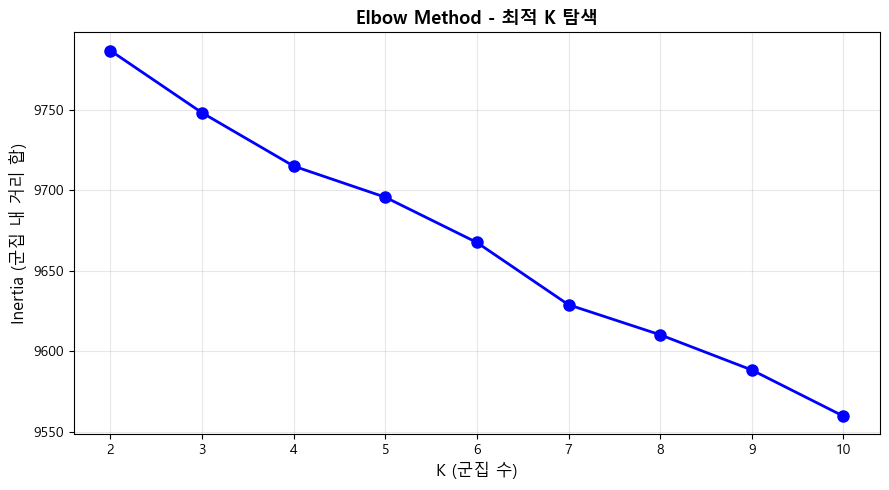

저장 완료 ✅

그래프에서 꺾이는 지점(elbow)이 최적 K입니다


In [19]:
# Elbow 그래프
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertia_list, 'bo-', linewidth=2, markersize=8)
ax.set_title('Elbow Method - 최적 K 탐색', fontsize=13, fontweight='bold')
ax.set_xlabel('K (군집 수)', fontsize=12)
ax.set_ylabel('Inertia (군집 내 거리 합)', fontsize=12)
ax.set_xticks(list(K_range))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/13_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')
print()
print('그래프에서 꺾이는 지점(elbow)이 최적 K입니다')

In [20]:
# ⚠️ Elbow 그래프 확인 후 최적 K 직접 설정
K_OPTIMAL = 4   # ← 그래프 보고 수정

print(f'K={K_OPTIMAL} 으로 K-Means 학습 중...')
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
kmeans.fit(X_sample)
cluster_labels = kmeans.labels_

df_sample['cluster'] = cluster_labels

print('K-Means 학습 완료 ✅')
print()
print('=== 군집별 데이터 수 ===')
print(df_sample['cluster'].value_counts().sort_index())

K=4 으로 K-Means 학습 중...
K-Means 학습 완료 ✅

=== 군집별 데이터 수 ===
cluster
0    2345
1     721
2     555
3    6379
Name: count, dtype: int64


In [21]:
# 군집별 긍/부정 비율 확인
print('=== 군집별 긍/부정 비율 ===')
cluster_summary = df_sample.groupby('cluster').agg(
    데이터수 = ('label', 'count'),
    긍정수   = ('label', 'sum'),
    평균별점 = ('score', 'mean')
).round(2)
cluster_summary['부정수']   = cluster_summary['데이터수'] - cluster_summary['긍정수']
cluster_summary['긍정비율'] = (cluster_summary['긍정수'] / cluster_summary['데이터수'] * 100).round(1)
print(cluster_summary)

=== 군집별 긍/부정 비율 ===
         데이터수   긍정수  평균별점   부정수  긍정비율
cluster                              
0        2345  1117  3.13  1228  47.6
1         721   528  3.98   193  73.2
2         555   462  4.34    93  83.2
3        6379  2892  3.07  3487  45.3


In [22]:
# 군집별 대표 단어 추출
print('=== 군집별 대표 단어 TOP10 ===')
centers = kmeans.cluster_centers_

for i in range(K_OPTIMAL):
    top_idx   = centers[i].argsort()[::-1][:10]
    top_words = [feature_names[j] for j in top_idx]
    pos_ratio = cluster_summary.loc[i, '긍정비율']
    avg_score = cluster_summary.loc[i, '평균별점']
    print(f'\n클러스터 {i} (긍정비율 {pos_ratio}%, 평균별점 {avg_score}점)')
    print(f'  대표 단어 : {" / ".join(top_words)}')

=== 군집별 대표 단어 TOP10 ===

클러스터 0 (긍정비율 47.6%, 평균별점 3.13점)
  대표 단어 : 하다 / 구매 / 구매 하다 / 사용 / 좋다 / 사용 하다 / 주문 / 주문 하다 / 재다 / 있다

클러스터 1 (긍정비율 73.2%, 평균별점 3.98점)
  대표 단어 : 먹다 / 맛있다 / 하다 / 재다 / 자다 먹다 / 자다 / 시키다 / 좋다 / 먹다 보다 / 보다

클러스터 2 (긍정비율 83.2%, 평균별점 4.34점)
  대표 단어 : 빠르다 / 배송 / 배송 빠르다 / 좋다 / 빠르다 배송 / 빠르다 좋다 / 감사하다 / 재다 / 하다 / 재다 배송

클러스터 3 (긍정비율 45.3%, 평균별점 3.07점)
  대표 단어 : 좋다 / 같다 / 있다 / 자다 / 이다 / 사다 / 않다 / 별로 / 없다 / 가격


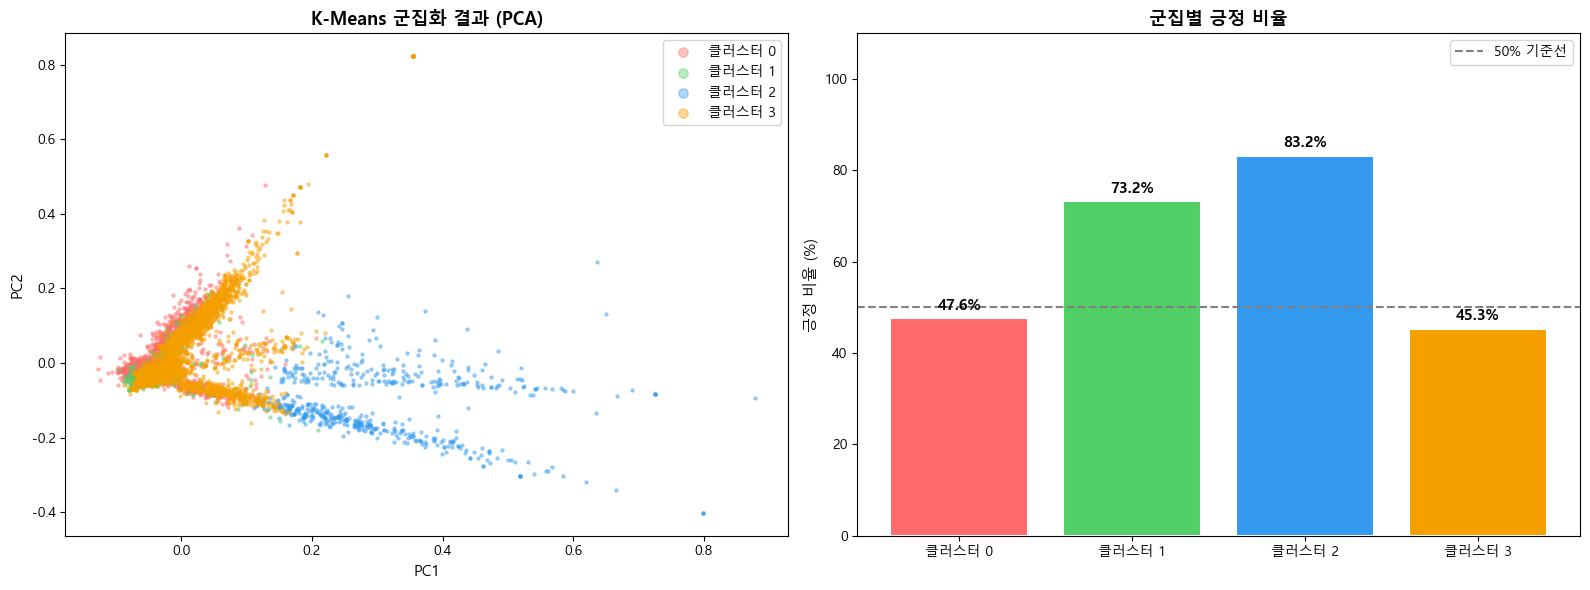

저장 완료 ✅


In [23]:
# K-Means 군집 PCA 시각화
cluster_colors = ['#FF6B6B', '#51CF66', '#339AF0', '#F59F00',
                  '#CC5DE8', '#20C997', '#FF922B', '#74C0FC']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 군집별 색상
for i in range(K_OPTIMAL):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[i], alpha=0.4, s=5, label=f'클러스터 {i}')
axes[0].set_title('K-Means 군집화 결과 (PCA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].legend(fontsize=10, markerscale=3)

# 군집별 긍정 비율 막대그래프
clusters    = cluster_summary.index.tolist()
pos_ratios  = cluster_summary['긍정비율'].tolist()
bar_colors  = [cluster_colors[i] for i in clusters]
bars = axes[1].bar([f'클러스터 {i}' for i in clusters],
                   pos_ratios, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1.5, label='50% 기준선')
axes[1].set_title('군집별 긍정 비율', fontsize=13, fontweight='bold')
axes[1].set_ylabel('긍정 비율 (%)', fontsize=11)
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=10)
for bar, val in zip(bars, pos_ratios):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/14_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 4. t-SNE
> PCA보다 더 정교한 차원축소 시각화
>
> 비선형 관계까지 포착 가능

```
PCA    : 선형 변환 → 빠르지만 단순
t-SNE  : 비선형 변환 → 느리지만 군집이 더 잘 보임
```


In [24]:
# t-SNE는 느리므로 3,000개만 샘플링
tsne_idx    = np.random.choice(len(X_sample), size=3000, replace=False)
X_tsne_in   = X_sample[tsne_idx]
df_tsne     = df_sample.iloc[tsne_idx].copy()  # 원본 인덱스 유지

print('t-SNE 변환 중... (수 분 소요)')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_in)
print('t-SNE 변환 완료 ✅')

t-SNE 변환 중... (수 분 소요)
t-SNE 변환 완료 ✅


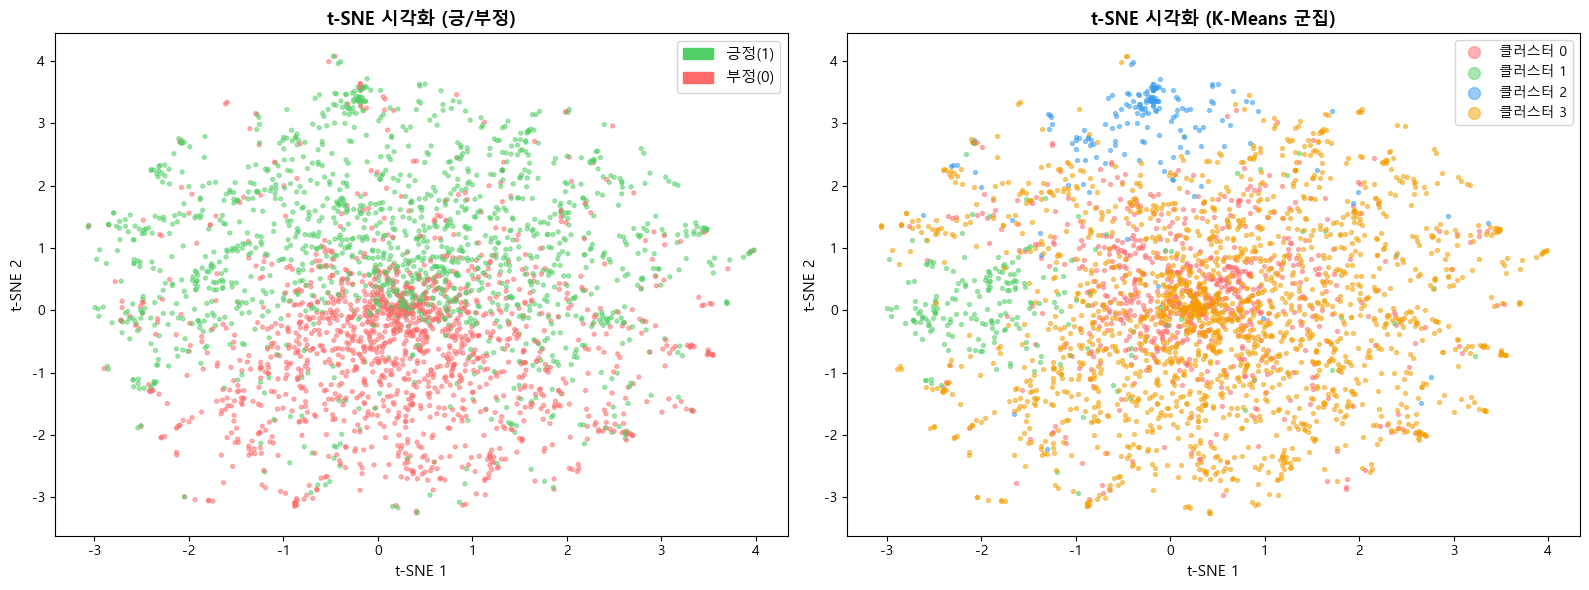

저장 완료 ✅


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 긍/부정 시각화
colors_tsne = df_tsne['label'].map({0: '#FF6B6B', 1: '#51CF66'})
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=colors_tsne, alpha=0.5, s=8)
axes[0].set_title('t-SNE 시각화 (긍/부정)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE 1', fontsize=11)
axes[0].set_ylabel('t-SNE 2', fontsize=11)
legend = [Patch(color='#51CF66', label='긍정(1)'),
          Patch(color='#FF6B6B', label='부정(0)')]
axes[0].legend(handles=legend, fontsize=11)

# K-Means 군집 시각화
cluster_tsne = df_tsne['cluster'].values
for i in range(K_OPTIMAL):
    mask = cluster_tsne == i
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=cluster_colors[i], alpha=0.5, s=8, label=f'클러스터 {i}')
axes[1].set_title('t-SNE 시각화 (K-Means 군집)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
axes[1].legend(fontsize=10, markerscale=3)

plt.tight_layout()
plt.savefig('../output/15_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 5. Tableau용 결과 저장

In [26]:
# 테스트 데이터 전체에 클러스터·PCA 예측 (배치 처리 - 메모리 절약)
print('테스트 데이터 전체 예측 중... (배치 처리)')
BATCH = 2000
test_clusters   = []
test_pca_coords = []

for start in range(0, X_test.shape[0], BATCH):
    batch = X_test[start:start+BATCH].toarray()
    test_clusters.extend(kmeans.predict(batch).tolist())
    test_pca_coords.extend(pca.transform(batch).tolist())

# 테스트 데이터 df 구성 (원본 인덱스 사용)
df_result = df.loc[y_clf_test.index].copy()
df_result['cluster'] = test_clusters
df_result['pca_x']   = [c[0] for c in test_pca_coords]
df_result['pca_y']   = [c[1] for c in test_pca_coords]

# t-SNE 결과 (sample 기반)
df_tsne_result = df_tsne.copy()
df_tsne_result['tsne_x'] = X_tsne[:, 0]
df_tsne_result['tsne_y'] = X_tsne[:, 1]

# 저장 (index=True : 원본 행 번호 보존 → 05_export에서 인덱스 기반 join)
df_result.to_csv('../output/unsupervised_results.csv',  index=True, encoding='utf-8-sig')
df_tsne_result.to_csv('../output/tsne_results.csv',     index=False, encoding='utf-8-sig')

print('Tableau용 CSV 저장 완료 ✅')
print()
print('저장된 파일 :')
print('  output/unsupervised_results.csv  ← PCA좌표 + 군집번호 (테스트 전체)')
print('  output/tsne_results.csv          ← t-SNE좌표 + 군집번호')
print()
df_result.head()

테스트 데이터 전체 예측 중... (배치 처리)
Tableau용 CSV 저장 완료 ✅

저장된 파일 :
  output/unsupervised_results.csv  ← PCA좌표 + 군집번호 (테스트 전체)
  output/tsne_results.csv          ← t-SNE좌표 + 군집번호



,score,content,label,content_len,content_clean,content_token,cluster,pca_x,pca_y
49081,5,"재구매 단맛,짠맛이 적당해서 맛있네요.",1,21,재구매 단맛 짠맛이 적당해서 맛있네요,재다 단맛 짠맛 적당하다 맛있다,1,-0.018195,-0.027485
112278,1,재구매 불량이 엄청나네요 사탕마다 죄다끈적거리고,0,26,재구매 불량이 엄청나네요 사탕마다 죄다끈적거리고,재다 불량 엄청나다 사탕 끈 거리,3,-0.019508,-0.020016
2770,2,작동이 잘안됐어요ㅠ,0,10,작동이 잘안됐어요,작동 돼다,3,-0.029365,-0.023802
45953,5,재구매 그럭저럭 마음에들고 좋아요.,1,19,재구매 그럭저럭 마음에들고 좋아요,재다 마음 들다 좋다,3,0.059460,0.135057
161037,2,좋아요 만족,0,6,좋아요 만족,좋다 만족,3,0.067388,0.172929


---

## 📝 비지도학습 결과 요약 및 결론

### 사용 모델

| 모델 | 목적 | 결과 |
|---|---|---|
| PCA | 10,000차원 → 2차원 압축 | 긍/부정 분리 ❌ 분포 확인 ✅ |
| K-Means (K=4) | 유사 리뷰 군집화 | 토픽별 군집화 ✅ 배송·식품 군집은 긍정 편향 ✅ |
| t-SNE | 비선형 차원축소 시각화 | 배송 군집만 분리 ✅ 나머지 혼재 ❌ |

---

### K-Means 군집 해석

| 군집 | 데이터 수 | 긍정비율 | 평균별점 | 대표 단어 | 해석 |
|---|---|---|---|---|---|
| 클러스터 0 | 2,345개 | 47.6% | 3.13점 | 구매 / 사용 / 주문 | 제품 사용 후기형 리뷰 |
| 클러스터 1 | 721개 | **73.2%** | 3.98점 | 먹다 / 맛있다 / 시키다 | 식품 카테고리 리뷰 |
| 클러스터 2 | 555개 | **83.2%** | 4.34점 | 배송 / 빠르다 / 배송빠르다 | 배송 중심 리뷰 |
| 클러스터 3 | 6,379개 | 45.3% | 3.07점 | 좋다 / 별로 / 가격 | 일반 감성 표현형 리뷰 |

---

### 핵심 발견

- **토픽 분리 성공** : label 없이도 식품 / 배송 / 제품후기 / 일반감성 카테고리를 자동으로 구분
- **배송·식품 군집의 긍정 편향** : 클러스터 2(배송, 83.2%)와 클러스터 1(식품, 73.2%)은 긍정 비율이 뚜렷하게 높음 → 배송 만족과 음식 맛에 대한 리뷰는 본질적으로 긍정적인 경향
- **일반 후기·제품 군집은 균등** : 클러스터 0(47.6%)과 클러스터 3(45.3%)은 긍/부정이 거의 반반 → 제품 품질 관련 리뷰는 의견이 갈림
- **배송 군집만 뚜렷이 분리** : t-SNE에서 클러스터 2(배송)만 섬처럼 독립적으로 분리

---

### 비지도학습이 완전한 긍/부정 분류에 한계가 있는 이유

> 지도학습은 정답(label)을 보면서 **"이 단어가 나오면 긍정이다"** 라는 규칙을 직접 학습함
> 반면 비지도학습은 정답 없이 **단어 패턴이 비슷한 것끼리** 묶을 뿐
>
> 긍정/부정 리뷰는 사용하는 단어 자체가 비슷하기 때문에
> (예: "배송 빠르고 좋아요" vs "배송 빠른데 품질 별로예요")
> K-Means는 주제(토픽) 기반으로 분리하며 감성 분리는 부분적으로만 나타남
>
> 결론적으로 **완전한 긍/부정 분류는 정답(label)이 있어야 가능**하지만
> 토픽 기반 군집에서 **배송·식품처럼 특정 카테고리의 감성 경향을 파악**하는 데는 유의미함

---

### 비지도학습이 의미있었던 부분

- **데이터 구조 파악** : PCA / t-SNE로 20만개 데이터의 전체 분포 확인
- **토픽 자동 발견** : label 없이도 식품 / 배송 / 일반 카테고리를 자동으로 구분
- **감성 경향 발견** : 배송(83.2%)·식품(73.2%) 군집의 높은 긍정 비율로 카테고리별 만족도 차이 확인
- **지도학습과의 비교** : label 유무가 성능에 얼마나 큰 영향을 미치는지 직접 확인

---